In [1]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import openai
from processing import (
    generate_comments,
    df_character_cleaning,
    get_comments_sentiment,
    comparison_table,
    get_movie_entities,
    TOTAL_SUMMARIZER,
    create_movie_info,
    generate_summary_marketing,
    process_comments_in_batches,
)
from config import movies
import re
from visualization import sentiment_viz, emotion_viz, display_comments_by_topic
from app import extract_youtube_id, extract_imdb_id, summarize_comments
load_dotenv()
import matplotlib.pyplot as plt
import seaborn as sns
from agentic import generate_marketing_suggestions, review_marketing_suggestions, improve_marketing_suggestions

/opt/homebrew/anaconda3/envs/socialsense/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/guillaumedherouville/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/guillaumedherouville/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertFor

In [2]:
youtube_ref = "https://www.youtube.com/watch?v=n9xhJrPXop4"
video_id = extract_youtube_id(youtube_ref)

imdb_ref = "https://www.imdb.com/title/tt1160419/"
movie_id = extract_imdb_id(imdb_ref)

In [3]:
comments = generate_comments(video_id, os.getenv("YT_KEY"), max_comments=1000)
comments = df_character_cleaning(comments)
#all_scores = get_comments_sentiment(st.session_state.comments)
#table = comparison_table(all_scores, movie_id, movies)

In [4]:
entities_df = get_movie_entities(movie_id)

In [5]:
movie_info = create_movie_info(movie_id, entities_df)

In [6]:
topics = summarize_comments(comments, movie_info)

2024-08-12 12:08:16.433 
  command:

    streamlit run /opt/homebrew/anaconda3/envs/socialsense/lib/python3.8/site-packages/ipykernel_launcher.py [ARGUMENTS]
2024-08-12 12:08:16.435 No runtime found, using MemoryCacheStorageManager


In [7]:
topics

['1. Cinematic quality with viewers praising stunning visuals, impressive special effects, and overall artistry enhancing the storytelling.  ',
 "2. Acclaim for Hans Zimmer's musical score and the soundtrack, which many noted elevated the film experience.  ",
 '3. Strong performances from Timothée Chalamet and the supporting cast, with commendations for their depth and audience engagement.  ',
 "4. Satisfaction with the film's faithfulness to the essence of the original Dune novel, appreciating thematic weight and character arcs presented.  ",
 '5. Anticipation for a sequel with commenters eager to see the continuation of the story and character developments.  ',
 '6. Critique of slow pacing, with many viewers feeling it detracted from narrative drive and caused boredom or disengagement.  ',
 '7. Concerns about weaknesses in character development, particularly for Jessica and other supporting characters, hindering emotional connections.  ',
 '8. Disappointment with adaptation choices, 

In [8]:
comments_topics_df = process_comments_in_batches(comments, topics, batch_size=50)

2024-08-12 12:08:52.793 No runtime found, using MemoryCacheStorageManager


matching in progressmatching in progress

matching in progress
matching in progress
matching in progress
matching in progress
matching in progress
matching in progress
matching in progress
matching in progress
matching in progress
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching done
matching done
matching done
matching done
matching done
matching done
matching done
matching done
matching done
matching done
matching done


In [9]:
def display_comments_by_topic(df):
    df = df.fillna(0)
    # Sum the counts across rows to get total counts for each topic
    df_counts = df.sum(axis=0).reset_index()
    df_counts.columns = ["Topic", "Count"]

    # Ensure all possible topics (1-10) are included by filling in missing topics with a count of 0
    all_topics = [str(i) for i in range(1, 11)]  # Topics numbered 1-10 as strings
    df_counts = df_counts.set_index("Topic")
    df_counts = df_counts.reindex(all_topics, fill_value=0).reset_index()

    # Convert 'Topic' column back to integer if needed
    df_counts["Topic"] = df_counts["Topic"].astype(int)

    # Plotting
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(18, 10))

    # Define your color palette
    muted_green = "#6dbf67"
    coolwarm_red = "#d73027"
    palette = [muted_green] * 5 + [
        coolwarm_red
    ] * 5  # First 5 bars in muted_green, next 5 in coolwarm_red

    # Create the count plot
    ax = sns.barplot(data=df_counts, x="Topic", y="Count", palette=palette)

    # Set plot background color
    plt.gcf().set_facecolor(".1")  # Set the background of the figure
    ax.set_facecolor(".1")  # Set the background of the axes

    # Set title and labels with a lighter color for visibility
    plt.title("Number of Comments by Topic", color="white")
    plt.xlabel("Topic", color="white")
    plt.ylabel("Count of Comments", color="white")

    # Change the color of the ticks and tick labels
    plt.xticks(color="white")
    plt.yticks(color="white")

    # Change the color of the axes' spines
    for spine in ax.spines.values():
        spine.set_edgecolor("white")

    # Adding the count above each bar
    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            xytext=(0, 5),
            textcoords="offset points",
        )

    # Calculate total counts for the first 5 and next 5 topics
    first_5_total = df_counts[df_counts["Topic"].isin(df_counts["Topic"].unique()[:5])][
        "Count"
    ].sum()
    next_5_total = df_counts[df_counts["Topic"].isin(df_counts["Topic"].unique()[5:])][
        "Count"
    ].sum()

    # Get current axes and calculate percentages
    ax = plt.gca()
    positive_perc = first_5_total / (first_5_total + next_5_total) * 100
    negative_perc = next_5_total / (first_5_total + next_5_total) * 100

    # Infographic text
    plt.text(
        7.8,
        ax.get_ylim()[1] * 0.92,
        f"POS : {positive_perc:.4g}%\nNEG : {negative_perc:.4g}%",
        color="white",
        fontweight="bold",
    )

    # Create the plot
    plt.show()

In [10]:
%matplotlib inline

/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_11008/1641174399.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_counts, x="Topic", y="Count", palette=palette)


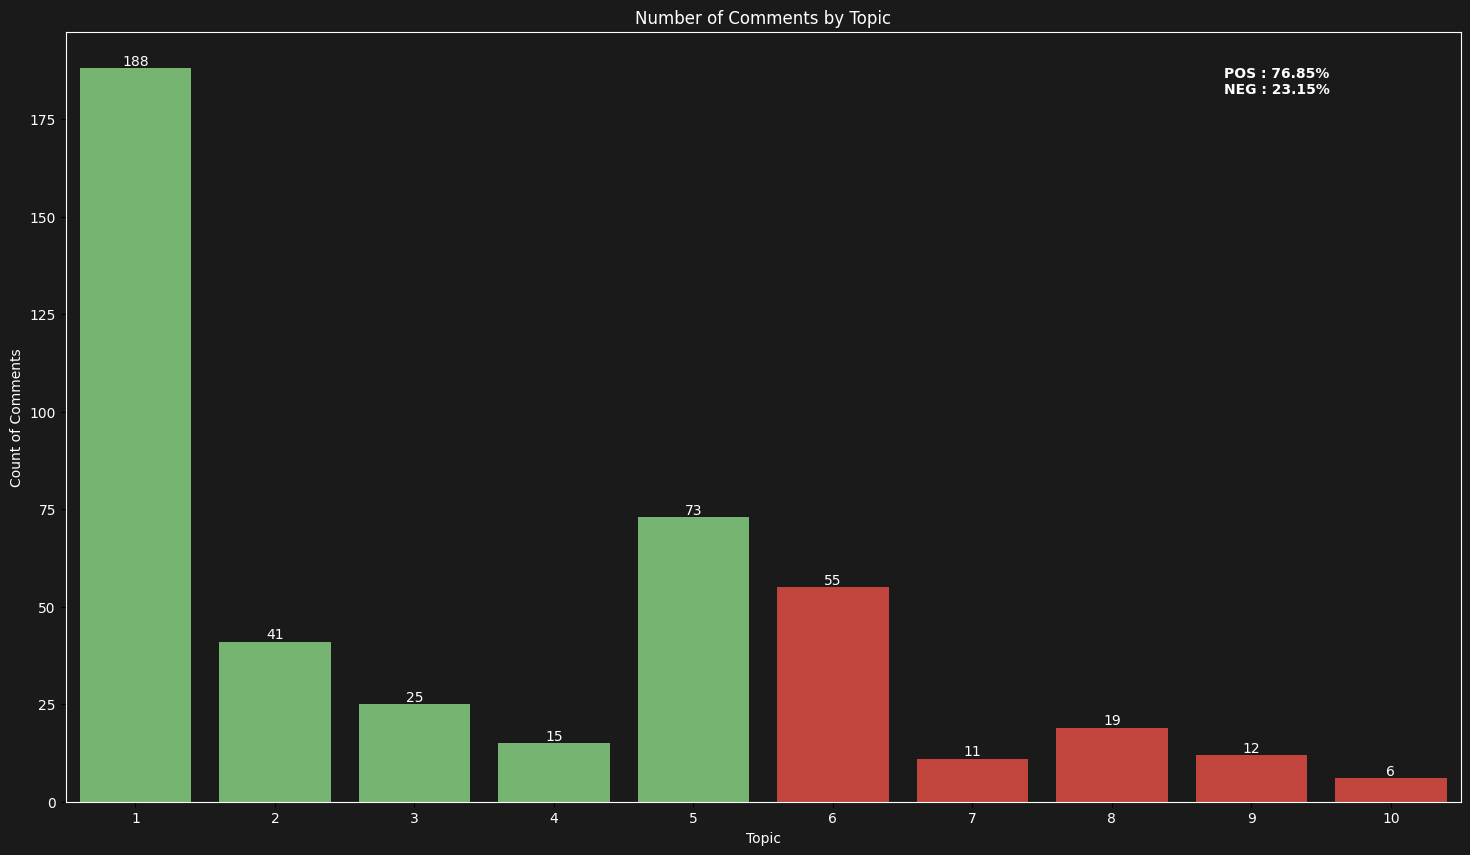

In [11]:
display_comments_by_topic(comments_topics_df)

## Marketing

In [12]:
class ChatGPT:
    def __init__(self, model="gpt-4o-mini", system_message=None):
        self.model = model
        self.client = openai.OpenAI()
        self.default_system_message = {"role": "system", "content": system_message}
        self.messages = [self.default_system_message]

    def add_user_message(self, message, reset_chat=False):
        if reset_chat:
            self.messages = [self.default_system_message]
        self.messages.append({"role": "user", "content": message})

    def get_response(self):
        completion = self.client.chat.completions.create(
            model=self.model, messages=self.messages
        )
        assistant_message = completion.choices[0].message.content
        self.messages.append({"role": "assistant", "content": assistant_message})
        return assistant_message


In [13]:
def generate_suggestions(topics, movie_info):
    analyst_prompt = f"""
    Here is information on the given film of interest: {movie_info}
    Here are the general topics people are discussing related to this film: \n {topics}
    Given the topics that users are speaking about your movie trailer, output 5 of the most relevant marketing suggestions you can concoct to help promote the film in list-format, with details for being included in application to this specific film.
    Please lend creative and specific suggestions to help market this film.
    Please ensure each suggestion is unique; do not repeat similar suggestions multiple times.
    Start directly with the list, do not include other text, and be concise (yet detailed) in your suggestions.
    """
    analyst = ChatGPT(
        system_message="You are a senior marketing analyst at a big movie production company. You are tasked with creating a set of marketing actions for a new movie, based on the topics that users are discussing. \
            You are in competition with another analyst for this task, one of you will be fired and the other promoted. For each reply, take a deep breath and think step by step."                
    )
    analyst.add_user_message(analyst_prompt)
    summarized_chunk = analyst.get_response()
    return summarized_chunk, analyst

In [14]:
critic = ChatGPT(
    system_message="You are a senior marketing associate at a big movie production company. You are tasked with guiding two junior analysts to provide optimal marketing actions for a new movie, based on the topics that users are discussing. \
    For each reply, take a deep breath and think step by step. I will tip you $100."
)
def review_suggestions(
    topics, movie_info, marketing_suggestions, critic, first_pass=False, final=False
):
    suffix = f"""
    Please review each suggestion and provide feedback on whether it is an appropriate marketing action considering feasibility, cost-effectiveness, general marketing science as well as public relations and social media knowledge. This feedback will be vital to improve our marketing strategy.
    Be extremely severe in your judgment, your career depends on it. If a suggestion is not relevant enough, you will be held responsible for not catching it and fired.
    At the beginning of your review, make sure to provide a clear ranking of the 10 suggestions, from best to worst.
    Conclude with a general comment on the overall quality of the suggestions, and what specific areas need improvement.
    Do not include meta information in your reply.
    """

    if first_pass==True:
        critic_prompt = f"""
        Here is information on the given film of interest: {movie_info}
        Here are the general topics people are discussing related to this film: \n {topics}
        Given the topics that users are speaking about your movie trailer, the two analysts have come up with the following marketing suggestions, in no particular order: {marketing_suggestions}
        {suffix}
        """
    else:
        critic_prompt = f"""
        Given your feedback, the two analysts have revised the marketing suggestions for the film. Here are the updated suggestions: {marketing_suggestions}
        {suffix}"""
    if final == True:
        critic_prompt = f"""
        Given your feedback, the two analysts have revised the marketing suggestions for the film. Here are the final updated suggestions: {marketing_suggestions}
        Please review each suggestion assign it a score based of whether it is an appropriate marketing action considering feasibility, cost-effectiveness, general marketing science as well as public relations and social media knowledge. This feedback will be vital to improve our marketing strategy.
        Be extremely severe in your judgment, your career depends on it. 
        Return the top 5 best unique suggestions, in list format, with the exact same format as it was provided by the analyst.
        Start directly with the list and do not include other text."""

    critic.add_user_message(critic_prompt)
    critic_message = critic.get_response()
    return critic_message, critic

In [15]:
def improve_suggestions(analyst, critic_message, competing_suggestions):
    analyst_prompt = f"""
        The other analyst has provided these suggestions: {competing_suggestions}
        Given all suggestions, an advanced reviewer from your team has provided the following ranking and explanation : {critic_message}
        Please review the feedback and provide a new set of 5 suggestions. You can keep some of the old ones if they are good enough, but you must provide at least 2 new suggestions which were in neither of the previous lists.
        Your suggestions must improve based on the feedback provided by the advanced reviewer, in a relevant manner.
        Output the revised suggestions in list-format, with details for each suggestion. Start directly with the list and do not include other text.
    """
    analyst.add_user_message(analyst_prompt)
    evaluations = analyst.get_response()
    return evaluations, analyst

#### Marketing #1

In [16]:
marketing_suggestions1, analyst1 = generate_marketing_suggestions(topics, movie_info)
print(marketing_suggestions1)

1. **Visual and Audio Experience Events**: Organize immersive screenings in select theaters featuring enhanced audio systems that highlight Hans Zimmer's musical score and the film’s stunning visuals. Complement these with an introduction by the director, Denis Villeneuve, and discussions with cinematographer Greig Fraser about the artistic choices made during filming.

2. **Behind-the-Scenes Documentary**: Release a short documentary series focused on the making of *Dune: Part One*, emphasizing the cinematography, visual effects, and Hans Zimmer's score. This can include interviews with key cast members like Timothée Chalamet, Rebecca Ferguson, and Denis Villeneuve, providing insights into character development and motivations, addressing critique points like pacing and character depth.

3. **Social Media Engagement and Challenges**: Launch a social media campaign inviting fans to post their interpretations of key characters or scenes through art, writing, or video formats. Use hashta

In [17]:
marketing_suggestions2, analyst2 = generate_marketing_suggestions(topics, movie_info)
print(marketing_suggestions2)

1. **Visually Immersive Art Installations**: Create pop-up art installations in key cities that replicate the stunning visuals of Dune: Part One. Incorporate elements from notable scenes, featuring augmented reality experiences where visitors can interact with desert landscapes, sandworms, and character highlights. This ties into the viewers' appreciation of cinematic artistry.

2. **Hans Zimmer Experience Live Concert**: Host a series of live concerts featuring Hans Zimmer’s musical score from the film, inviting audiences to experience the music with a full orchestra. Pair performances with immersive visuals from the film to create a sensory journey that enhances the soundtrack's acclaim, drawing in fans of both film and music.

3. **Character Deep-Dive Web Series**: Develop a web series exploring character backstories, especially those of Paul Atreides and Lady Jessica. Each episode can highlight their development and motivations, addressing the critiques of character depth while rei

In [18]:
all_suggestions1 = marketing_suggestions1 + marketing_suggestions2
critic_message1, critic = review_suggestions(
    topics, movie_info, all_suggestions1, critic, first_pass=True)
print(critic_message1)

1. **Social Media Engagement and Challenges**
2. **Character Deep-Dive Web Series**
3. **Engaging Social Media Campaign with Cast**
4. **Sequel Teaser and Fan Events**
5. **Visual and Audio Experience Events**
6. **Hans Zimmer Experience Live Concert**
7. **Merchandise Featuring Character Depth**
8. **Behind-the-Scenes Documentary**
9. **Fan Voting for Sequel Elements**
10. **Visually Immersive Art Installations**

**Feedback:**

1. **Social Media Engagement and Challenges**: This is an excellent suggestion as it taps into the current trend of user-generated content and community engagement. It harnesses the excitement surrounding the characters and allows fans to express their creativity, which is both feasible and cost-effective. 

2. **Character Deep-Dive Web Series**: This is highly relevant as it addresses concerns about character development and will resonate well with fans. It is cost-effective, especially if integrated into existing streaming platforms, and enhances viewer unde

#### Marketing #2

In [19]:
revised_suggestions1, analyst_1 = improve_suggestions(analyst1, critic_message1, marketing_suggestions2)
print(revised_suggestions1)

1. **Enhanced Social Media Challenges and Polls**: Expand the initial social media engagement strategy to include regular themed challenges (e.g., art, fan fiction) along with weekly polls about character favorites or potential plot elements. This maintains ongoing interaction and builds anticipation while allowing fans to influence minor aspects, fostering a sense of community and involvement.

2. **Character Deep-Dive Web Series**: Continue the development of the character-focused web series but add elements that respond directly to viewer critiques, such as episodes dedicated to unpacking the motivations and developments of Jessica and other supporting characters. Incorporating insights from cast members and industry experts could also deepen engagement and understanding.

3. **Interactive Q&A with Behind-the-Scenes Content**: Combine elements of fan interaction with behind-the-scenes insights by organizing live Q&A sessions featuring cast members and the director, discussing key pr

In [20]:
revised_suggestions2, analyst_2 = improve_suggestions(analyst1, critic_message1, marketing_suggestions1)
print(revised_suggestions2)

1. **Optimized Social Media Challenges and User-Generated Content**: Launch a month-long campaign encouraging fans to create and share their own interpretations of *Dune* through various forms of art and storytelling. Following the initial success of the #DuneChallenge, integrate weekly themes (e.g., character portraits, alternative endings) to keep engagement fresh, while featuring the best entries on official channels to celebrate fan creativity.

2. **Interactive Character Deep-Dive Virtual Panels**: Organize a series of virtual panels focused on key characters from the film, facilitated by a popular sci-fi influencer or moderator. These panels would encourage discussions about character motivations and connections to the original novel, addressing viewer critiques directly and allowing fan participation through live Q&A, making it both informative and community-driven.

3. **Behind-the-Scenes Live Stream Events**: Instead of a pre-produced documentary, host live-streamed discussion

In [21]:
all_suggestions2 = revised_suggestions1 + revised_suggestions2
critic_message2, critic = review_suggestions(_, _, all_suggestions2, critic)
print(critic_message2)

1. **Enhanced Social Media Challenges and Polls**
2. **Optimized Social Media Challenges and User-Generated Content**
3. **Interactive Character Deep-Dive Virtual Panels**
4. **Character Deep-Dive Web Series**
5. **Behind-the-Scenes Live Stream Events**
6. **Short-Form Storytelling via TikTok**
7. **Mini Animated Shorts or Comics**
8. **Exclusive Virtual Reality Experiences**
9. **Augmented Reality Character Exploration App**
10. **Interactive Q&A with Behind-the-Scenes Content**

**Feedback:**

1. **Enhanced Social Media Challenges and Polls**: This is a strong strategy that promotes continuous engagement and connection with the fan base. The combination of thematic challenges and polls boosts interaction effectively, creating a sense of community and excitement that is highly feasible and cost-effective.

2. **Optimized Social Media Challenges and User-Generated Content**: This suggestion builds well on the previous ideas, keeping fan engagement fresh while fostering creativity. The 

#### Marketing #3

In [22]:
final_suggestions1, analyst_1 = improve_suggestions(analyst1, critic_message2, marketing_suggestions2)
print(final_suggestions1)

1. **Weekly Themed Social Media Challenges**: Build on the success of previous social media campaigns by launching weekly themed challenges that encourage fans to post artwork, cosplay, or creative interpretations of specific moments or characters from *Dune: Part One*. Each week could have a unique prompt, such as "Sandworm Week" or "Paul Atreides Day," enhancing continuous engagement and incentivizing participation through features on the official movie page or small prize giveaways.

2. **Guest Influencer-Led Character Discussions**: Organize a series of virtual discussions featuring popular social media influencers or sci-fi authors who resonate with the *Dune* themes. These discussions can focus on character motivations and adaptations from the book, allowing fans to hear varied perspectives and fostering deeper connections within the fan base.

3. **Fan Art Spotlight on Official Channels**: Create a dedicated segment on the official film’s social media channels that showcases fan

In [23]:
final_suggestions2, analyst_2 = improve_suggestions(analyst2, critic_message2, marketing_suggestions1)
print(final_suggestions2)

1. **Enhanced Social Media Challenges and Polls**: Launch a multi-platform campaign featuring themed challenges where fans can submit creative content related to the film’s characters, settings, or quotes. Polls can gauge fan interest in possible plot developments for the sequel or character backstories. By featuring top entries on official channels, this fosters engagement, community-building, and excitement while keeping costs low.

2. **Interactive Character Deep-Dive Virtual Panels**: Organize a series of live virtual panels focusing on key characters, where fans can interact with influencers or guest speakers who discuss character arcs, motivations, and development. This approach creates an educational element that ties back to viewer critiques and enhances fan connections, all while utilizing platforms that audiences actively engage with.

3. **Short-Form Storytelling via TikTok**: Create a playbook for a short-form TikTok series that tells quick stories or fun facts about the Du

In [24]:
final_suggestions = final_suggestions1 + final_suggestions2
critic_message2, critic = review_suggestions(_, _, final_suggestions, critic, _, final=True)
print(critic_message2)

1. **Weekly Themed Social Media Challenges**: Build on the success of previous social media campaigns by launching weekly themed challenges that encourage fans to post artwork, cosplay, or creative interpretations of specific moments or characters from *Dune: Part One*. Each week could have a unique prompt, such as "Sandworm Week" or "Paul Atreides Day," enhancing continuous engagement and incentivizing participation through features on the official movie page or small prize giveaways.

2. **Guest Influencer-Led Character Discussions**: Organize a series of virtual discussions featuring popular social media influencers or sci-fi authors who resonate with the *Dune* themes. These discussions can focus on character motivations and adaptations from the book, allowing fans to hear varied perspectives and fostering deeper connections within the fan base.

3. **Fan Art Spotlight on Official Channels**: Create a dedicated segment on the official film’s social media channels that showcases fan